# Eksplorasi: Customer Lifetime Value (CLV) Prediction

Tujuan notebook ini: Mengecek kekuatan prediktif dari data perilaku belanja 30 hari pertama terhadap total pendapatan (Revenue) pelanggan di masa depan.

**Pendekatan:** Karena target kita (`target_future_clv_revenue`) adalah nilai uang (kontinu), kita akan menggunakan model **Regresi**, bukan Klasifikasi.

Struktur:
1. Load parquet & cek struktur dasar
2. Distribusi Target (Histogram Revenue)
3. Diagnostik Korelasi (Pearson/Spearman)
4. Baseline Regresi Cepat (XGBRegressor)
5. Kesimpulan

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 1. Load Parquet
Pastikan tabel dbt `ml_customer_clv_training` sudah diekspor ke Parquet.

In [2]:
# Gunakan huruf 'r' di depan tanda kutip agar Windows membaca path dengan benar
PARQUET_DIR = r"D:\PREP_INTERN\PROJECT_DATAFLOW_SIMULATION\datasets\parquet"

# Gabungkan path dengan nama file CLV
PARQUET_FILE = os.path.join(PARQUET_DIR, "ml_customer_clv_latest.parquet")

df = pd.read_parquet(PARQUET_FILE)

print(f"Shape: {df.shape}")
df.head(20)

Shape: (15366, 14)


,user_id,cohort_date,target_future_clv_revenue,user_age,user_gender,user_country,acquisition_channel,first_30d_frequency,first_30d_monetary,first_30d_aov,first_30d_discount_enjoyed,first_30d_unique_categories,first_30d_returned_orders,first_30d_cancelled_orders
0,56219.0,2021-05-28,0.0,60,F,United States,Facebook,1,74.99,74.990000,0.0,1,0,0
1,39594.0,2019-02-11,0.0,17,M,China,Search,1,51.96,51.960000,0.0,1,0,0
2,34374.0,2020-08-11,0.0,27,M,United Kingdom,Search,1,84.19,42.095000,0.0,2,0,0
3,91794.0,2019-11-05,0.0,43,F,Brasil,Search,1,64.00,64.000000,0.0,1,0,0
4,11622.0,2019-01-19,0.0,23,F,China,Display,1,28.00,28.000000,0.0,1,0,0
5,23839.0,2019-01-06,0.0,24,F,Brasil,Search,1,127.00,42.333333,0.0,2,0,0
6,35234.0,2020-01-14,0.0,21,F,Brasil,Search,1,13.50,13.500000,0.0,1,0,0
7,41518.0,2019-09-30,0.0,64,M,China,Search,1,50.19,25.095000,0.0,2,0,0
8,47464.0,2020-01-12,0.0,27,M,Brasil,Search,1,119.00,119.000000,0.0,1,0,0
9,2349.0,2019-10-30,0.0,24,M,China,Search,1,60.00,60.000000,0.0,1,0,0


## 2. Distribusi Target CLV
Biasanya, CLV sangat *skewed* ke kanan (banyak pengguna berbelanja 0 di masa depan, sedikit "Whales" yang belanja sangat besar).

Persentase user dengan $0 Future Revenue: 99.54%


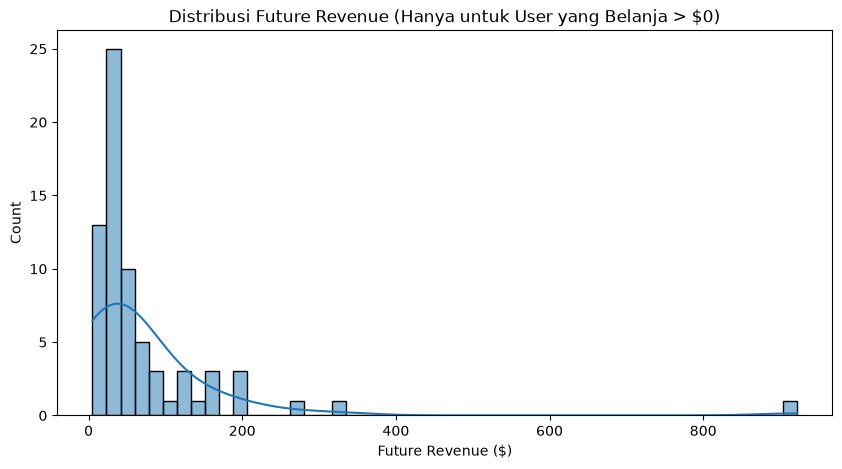

In [3]:
target_col = "target_future_clv_revenue"

# Cek berapa % user yang sama sekali tidak belanja lagi (Churn di bulan berikutnya)
zero_revenue_pct = (df[target_col] == 0).mean() * 100
print(f"Persentase user dengan $0 Future Revenue: {zero_revenue_pct:.2f}%")

plt.figure(figsize=(10, 5))
sns.histplot(df[df[target_col] > 0][target_col], bins=50, kde=True)
plt.title("Distribusi Future Revenue (Hanya untuk User yang Belanja > $0)")
plt.xlabel("Future Revenue ($)")
plt.show()

## 3. Diagnostik Korelasi (Sinyal Fitur)
Melihat korelasi Spearman (baik untuk data non-linear) antara fitur numerik di 30 hari pertama dengan masa depan.

In [4]:
exclude_cols = ['user_id', 'cohort_date', target_col]
feature_cols = [c for c in df.columns if c not in exclude_cols]

numeric_features = df[feature_cols].select_dtypes(include=['number']).columns.tolist()

print("=" * 60)
print("KORELASI SPEARMAN vs target_future_clv_revenue")
print("=" * 60)

corr_matrix = df[numeric_features + [target_col]].corr(method='spearman')
target_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)

for feat, score in target_corr.items():
    print(f"{feat:<35s} Corr = {score:.4f}")

KORELASI SPEARMAN vs target_future_clv_revenue
first_30d_cancelled_orders          Corr = 0.0109
user_age                            Corr = 0.0006
first_30d_unique_categories         Corr = -0.0028
first_30d_frequency                 Corr = -0.0038
first_30d_aov                       Corr = -0.0059
first_30d_monetary                  Corr = -0.0071
first_30d_returned_orders           Corr = -0.0084
first_30d_discount_enjoyed          Corr = nan


## 4. Baseline Regresi Cepat (XGBoost)
Kita mengukur performa awal menggunakan R-Squared ($R^2$) dan Mean Absolute Error (MAE).

In [5]:
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[feature_cols]
y = df[target_col]

categorical_features = [c for c in feature_cols if c not in numeric_features]

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value=0))])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder())
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
], remainder='drop')

# Gunakan XGBRegressor untuk tugas regresi berkelanjutan
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        objective='reg:squarederror', tree_method='hist',
        random_state=42, n_jobs=2
    ))
])

# 5-Fold Cross Validation
oof_preds = cross_val_predict(
    pipeline, X, y,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=1
)

# Evaluasi
mae = mean_absolute_error(y, oof_preds)
rmse = np.sqrt(mean_squared_error(y, oof_preds))
r2 = r2_score(y, oof_preds)

print("\n" + "=" * 50)
print("EVALUASI REGRESI (Out-of-Fold)")
print("=" * 50)
print(f"R-Squared (R2) Score : {r2:.4f}")
print(f"Mean Absolute Error  : ${mae:.2f}")
print(f"Root Mean Sq Error   : ${rmse:.2f}")
print("=" * 50)

# Feature Importance
pipeline.fit(X, y)
xgb_model = pipeline.named_steps['regressor']
semua_fitur = numeric_features + categorical_features

importance_df = pd.DataFrame({
    'Feature': semua_fitur,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\nTOP 10 FEATURE IMPORTANCE:")
print(importance_df.head(10))



EVALUASI REGRESI (Out-of-Fold)
R-Squared (R2) Score : -1.2015
Mean Absolute Error  : $0.82
Root Mean Sq Error   : $14.09

TOP 10 FEATURE IMPORTANCE:
                       Feature  Importance
0           first_30d_monetary    0.678684
1                first_30d_aov    0.068244
2          acquisition_channel    0.062901
3          first_30d_frequency    0.044641
4   first_30d_cancelled_orders    0.042458
5                     user_age    0.040947
6                 user_country    0.034768
7                  user_gender    0.020186
8  first_30d_unique_categories    0.006307
9    first_30d_returned_orders    0.000863


In [6]:
df

,user_id,cohort_date,target_future_clv_revenue,user_age,user_gender,user_country,acquisition_channel,first_30d_frequency,first_30d_monetary,first_30d_aov,first_30d_discount_enjoyed,first_30d_unique_categories,first_30d_returned_orders,first_30d_cancelled_orders
0,56219.0,2021-05-28,0.0,60,F,United States,Facebook,1,74.99,74.990,0.0,1,0,0
1,39594.0,2019-02-11,0.0,17,M,China,Search,1,51.96,51.960,0.0,1,0,0
2,34374.0,2020-08-11,0.0,27,M,United Kingdom,Search,1,84.19,42.095,0.0,2,0,0
3,91794.0,2019-11-05,0.0,43,F,Brasil,Search,1,64.00,64.000,0.0,1,0,0
4,11622.0,2019-01-19,0.0,23,F,China,Display,1,28.00,28.000,0.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15361,37924.0,2021-06-27,0.0,53,F,United Kingdom,Search,1,88.00,88.000,0.0,1,0,0
15362,78984.0,2021-07-01,0.0,43,F,South Korea,Display,1,100.00,100.000,0.0,1,0,0
15363,70409.0,2021-07-02,0.0,41,F,France,Facebook,1,117.50,29.375,0.0,4,0,0
15364,58252.0,2021-06-30,0.0,36,F,United Kingdom,Organic,1,35.00,35.000,0.0,1,0,0


In [7]:
df["target_future_clv_revenue"].describe()

count    15366.000000
mean         0.338108
std          9.497600
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        921.990000
Name: target_future_clv_revenue, dtype: float64